In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB # naive bayes multinomial para clasificación
from sklearn.metrics import accuracy_score # métrica de evaluación

# Análisis Exploratorio

In [19]:
df_nasa = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/asteroids_nasa.csv')
df_nasa.head(5)

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [20]:
# verificamos los tipos de datos
df_nasa.dtypes

Neo Reference ID                  int64
Name                              int64
Absolute Magnitude              float64
Est Dia in KM(min)              float64
Est Dia in KM(max)              float64
Est Dia in M(min)               float64
Est Dia in M(max)               float64
Est Dia in Miles(min)           float64
Est Dia in Miles(max)           float64
Est Dia in Feet(min)            float64
Est Dia in Feet(max)            float64
Close Approach Date                 str
Epoch Date Close Approach         int64
Relative Velocity km per sec    float64
Relative Velocity km per hr     float64
Miles per hour                  float64
Miss Dist.(Astronomical)        float64
Miss Dist.(lunar)               float64
Miss Dist.(kilometers)          float64
Miss Dist.(miles)               float64
Orbiting Body                       str
Orbit ID                          int64
Orbit Determination Date            str
Orbit Uncertainity                int64
Minimum Orbit Intersection      float64


In [21]:
print("Tamaño del dataframe : {}".format(df_nasa.shape))

Tamaño del dataframe : (4687, 40)


In [22]:
# Verificamos si hay valores nulos para imputar
df_nasa.isnull().sum()[df_nasa.isnull().sum()>0]

Series([], dtype: int64)

Hazardous
False    3932
True      755
Name: count, dtype: int64


<Axes: xlabel='Hazardous', ylabel='count'>

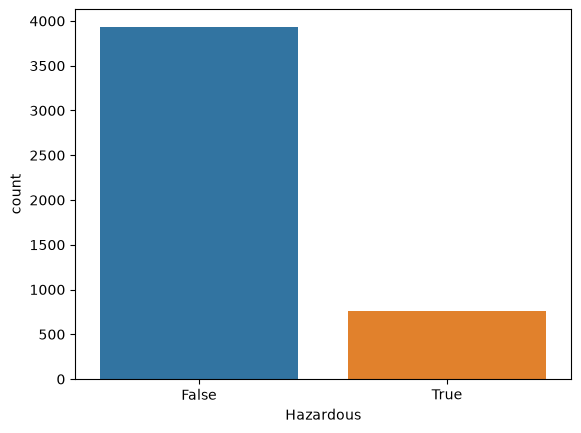

In [23]:
# Analisis de la distribución de la variable target "Hazardous"
print( df_nasa.Hazardous.value_counts() )
sns.countplot(x='Hazardous', data=df_nasa, hue='Hazardous', legend=False)

# Correlación de Variables

<Axes: >

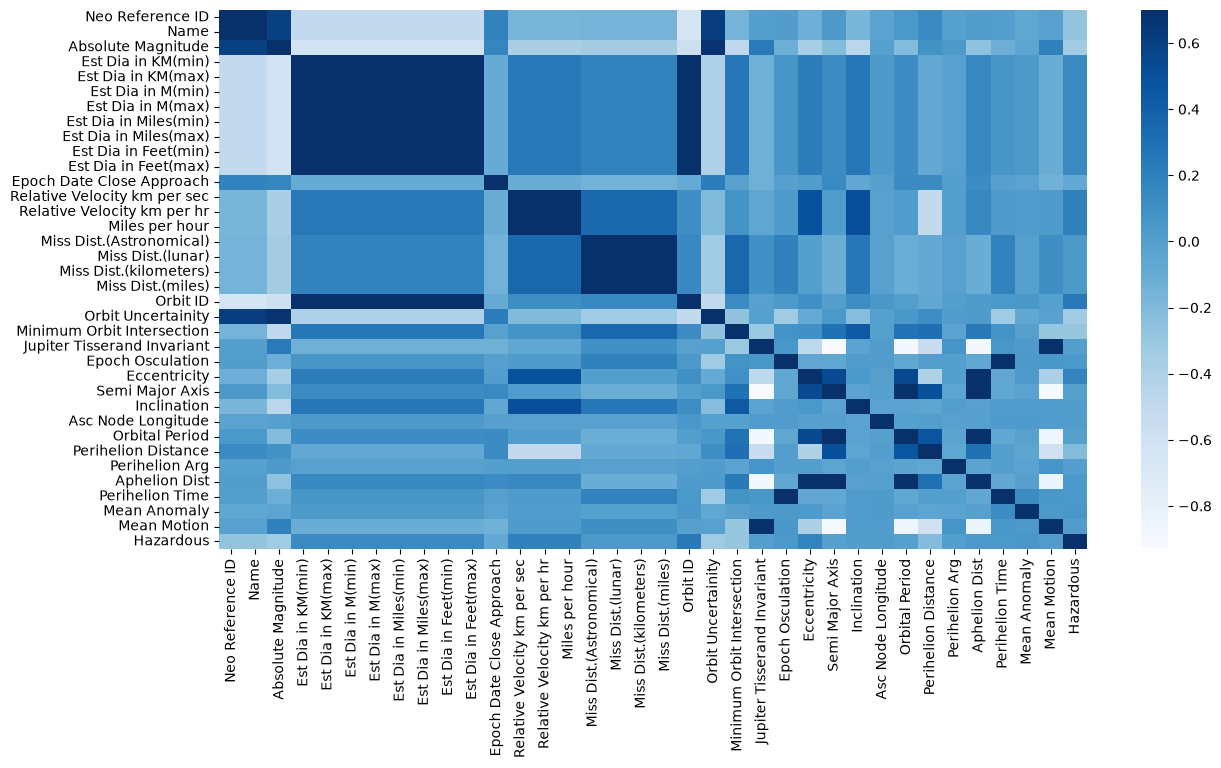

In [24]:
plt.figure(figsize=(14,7))
sns.heatmap(df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr(), vmax=.7, cmap ='Blues', fmt=".2f")

In [25]:
df_nasa_corr = df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr()[["Hazardous"]]*100 # lo pasamos a porcentajes
df_nasa_corr = df_nasa_corr.drop("Hazardous", axis=0) # eliminamos la variable target
df_nasa_corr = abs(df_nasa_corr) # nos interesa el valor absouluto
df_nasa_corr = df_nasa_corr.sort_values(["Hazardous"], ascending=False) # ordenamos en forma descendente
df_nasa_corr

,Hazardous
Orbit Uncertainity,32.872134
Absolute Magnitude,32.552193
Minimum Orbit Intersection,28.894902
Name,26.902814
Neo Reference ID,26.902814
Orbit ID,24.736904
Perihelion Distance,20.702693
Relative Velocity km per sec,19.197018
Miles per hour,19.197018
Relative Velocity km per hr,19.197018


# Seleccionamos las variables que vamos a utilizar y hacemos el Split

In [26]:
# dropeo ['Orbiting Body','Equinox'] porque en todos los casos es earth y J2000
df_nasa.drop(['Orbiting Body','Equinox'],axis=1, inplace=True)

In [27]:
df_nasa.columns

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit ID',
       'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Hazardous'],
      dtype='str')

In [28]:
df = df_nasa.drop(['Close Approach Date','Orbit Determination Date'],axis=1)
X_nasa = df.drop("Hazardous",axis=1)
y_nasa = df["Hazardous"]
X_nasa.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


In [29]:
# Hacemos el Split 70-30 para train-test
X_train, X_test, y_train, y_test = train_test_split(X_nasa, y_nasa, test_size=0.3, stratify = y_nasa, random_state=0)

In [30]:
# Creamos y entrenamos el clasificador bayesiano
bayes_multi = MultinomialNB()
bayes_multi.fit(X_train, y_train) # entrenamos el clasificador

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2752., 528.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.18,-1.83]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[bool](2,)","[False, True]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 35)","[[9.17e+09,9.17e+09,6.24e+04,...,6.76e+09,4.92e+05,2.02e+03], [1.55e+09,1.55e+09,1.06e+04,...,1.30e+09,1.03e+05,3.95e+02]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 35)","[[-12.78,-12.78,-24.68,...,-13.09,-22.61,-28.11], [-12.87,-12.87,-24.76,...,-13.04,-22.49,-28.05]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](35,)","['Neo Reference ID','Name','Absolute Magnitude',...,'Perihelion Time', 'Mean Anomaly','Mean Motion']"


In [31]:
y_pred_nb = bayes_multi.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_nb)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_nb))

Exactitud (accuracy) del modelo: 49.96 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.85      0.49      0.62      1180
        True       0.17      0.55      0.26       227

    accuracy                           0.50      1407
   macro avg       0.51      0.52      0.44      1407
weighted avg       0.74      0.50      0.56      1407



In [32]:
# Importamos otra librería para modelos naive bayes gausianos
from sklearn.naive_bayes import GaussianNB # naive bayes multinomial para clasificación

bayes_gauss = GaussianNB()
bayes_gauss.fit(X_train, y_train) # entrenamos el clasificador

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[2752., 528.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.84,0.16]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[bool](2,)","[False, True]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.975e+13
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](35,)","['Neo Reference ID','Name','Absolute Magnitude',...,'Perihelion Time', 'Mean Anomaly','Mean Motion']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,35
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 35)","[[3330580.01,3330580.01, 22.69,...,2457720.49, 178.95, 0.73], [2933011.6 ,2933011.6 , 20.09,...,2457796.14, 194.98, 0.75]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 35)","[[4.00e+13,4.00e+13,3.98e+13,...,3.98e+13,3.98e+13,3.98e+13], [4.02e+13,4.02e+13,3.98e+13,...,3.98e+13,3.98e+13,3.98e+13]]"


In [33]:
# Calculamos y mostramos la matriz de confusión del modelo
y_pred_gauss = bayes_gauss.predict(X_test)
#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_gauss)*100))
print("-"*100)

print(classification_report(y_test,y_pred_gauss))

Exactitud (accuracy) del modelo: 83.87 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.84      1.00      0.91      1180
        True       0.00      0.00      0.00       227

    accuracy                           0.84      1407
   macro avg       0.42      0.50      0.46      1407
weighted avg       0.70      0.84      0.77      1407



c:\Users\maxam\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maxam\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maxam\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

# Ejercicio

- identificar el parametro que estratifica el split del experimento
- ¿Qué supuesto realiza Naive Bayes sobre las variables predictoras? ¿Observando la matriz de correlación, este supuesto parece razonable para este dataset?
- remover las variables redundantes/altamente codependientes como 'Est Dia in M(min)' y 'Est Dia in Miles(min)'
- ¿Que pasa con el accuracy en este ejercicio? ¿es el mejor indicador posible?

Hazardous
Que las variables son independientes entre si. No
Pasapalabra
No, el accuracy no es el mejor indicador acá, porque el dataset está desbalanceado.